## 深度学习中常见的分布函数

| 分布 | 典型用途 |
|------|---------|
| 正态分布（高斯分布） | 权重初始化（Xavier/He）、VAE 隐变量、噪声建模 |
| 均匀分布 | 权重初始化、随机采样 |
| 伯努利分布 | 二分类输出、Dropout mask |
| 拉普拉斯分布 | L1 正则化先验、鲁棒回归 |
| Beta 分布 | Mixup 数据增强、VAE 先验 |

---

## 正态分布（高斯分布）

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- $\mu$：均值，控制分布中心
- $\sigma$：标准差，控制分布宽窄
- 记作 $X \sim \mathcal{N}(\mu, \sigma^2)$

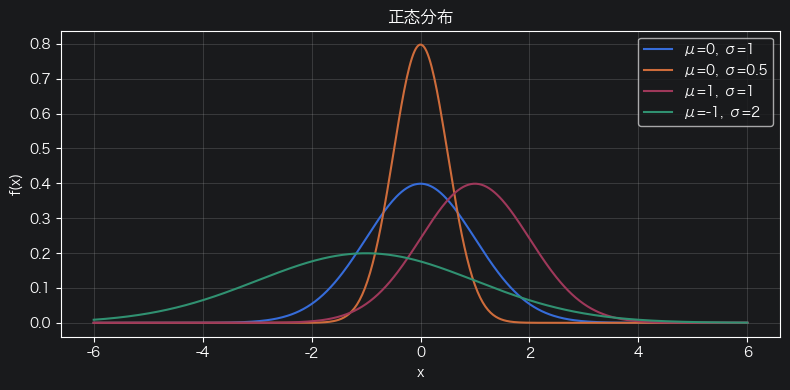

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 直接注册字体文件，绕过 matplotlib 字体缓存
fm.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

x = np.linspace(-6, 6, 500)
params = [(0, 1), (0, 0.5), (1, 1), (-1, 2)]

plt.figure(figsize=(8, 4))
for mu, sigma in params:
    y = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    plt.plot(x, y, label=f'μ={mu}, σ={sigma}')
plt.title('正态分布')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 均匀分布

$$f(x) = \begin{cases} \dfrac{1}{b-a} & a \leq x \leq b \\ 0 & \text{otherwise} \end{cases}$$

- 区间 $[a, b]$ 内概率密度恒为常数，区间外为 0
- 记作 $X \sim \mathcal{U}(a, b)$

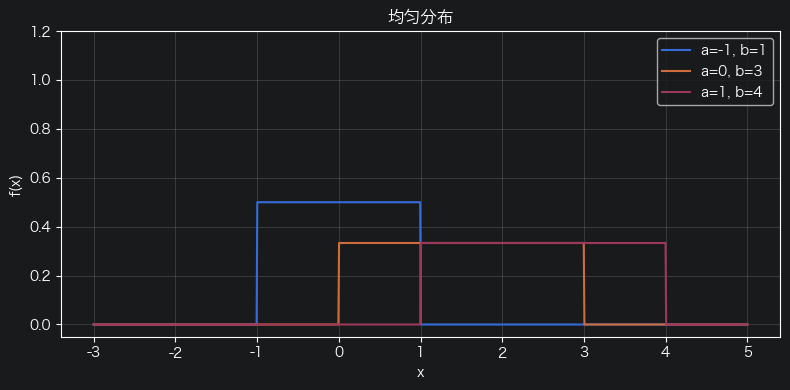

In [37]:
x = np.linspace(-3, 5, 1000)
params = [(-1, 1), (0, 3), (1, 4)]

plt.figure(figsize=(8, 4))
for a, b in params:
    y = np.where((x >= a) & (x <= b), 1 / (b - a), 0)
    plt.plot(x, y, label=f'a={a}, b={b}')
plt.title('均匀分布')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-0.05, 1.2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 伯努利分布

$$P(X = k) = p^k (1-p)^{1-k}, \quad k \in \{0, 1\}$$

- $p$：事件发生的概率，$1-p$：不发生的概率
- 记作 $X \sim \text{Bernoulli}(p)$
- 深度学习中用于二分类输出（sigmoid + BCELoss）和 Dropout mask

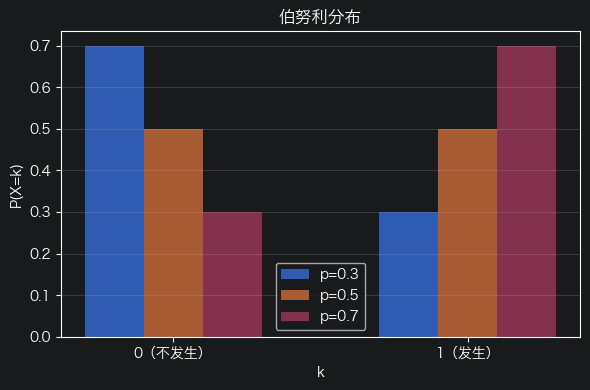

In [38]:
p_vals = [0.3, 0.5, 0.7]
x = np.array([0, 1])
width = 0.2
offsets = np.linspace(-width, width, len(p_vals))

plt.figure(figsize=(6, 4))
for offset, p in zip(offsets, p_vals):
    probs = [1 - p, p]
    plt.bar(x + offset, probs, width=width, label=f'p={p}', alpha=0.8)
plt.title('伯努利分布')
plt.xlabel('k')
plt.ylabel('P(X=k)')
plt.xticks([0, 1], ['0（不发生）', '1（发生）'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 拉普拉斯分布

$$f(x) = \frac{1}{2b}\exp\!\left(-\frac{|x - \mu|}{b}\right)$$

- $\mu$：位置参数（均值），$b$：尺度参数（控制宽窄）
- 记作 $X \sim \text{Laplace}(\mu, b)$
- 比正态分布有更重的尾部；以拉普拉斯分布为先验，等价于对参数施加 **L1 正则化**

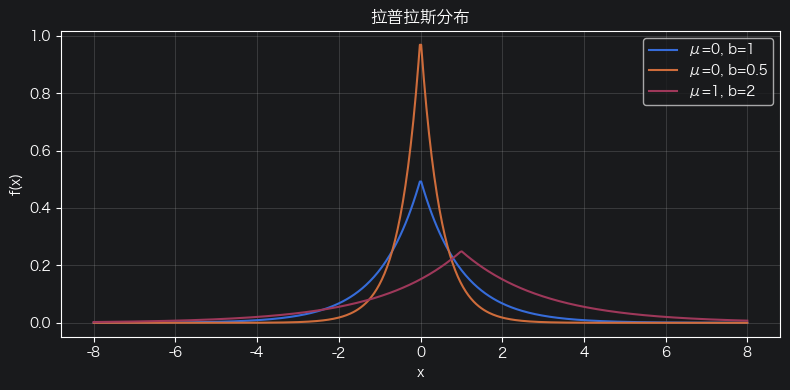

In [39]:
x = np.linspace(-8, 8, 500)
params = [(0, 1), (0, 0.5), (1, 2)]

plt.figure(figsize=(8, 4))
for mu, b in params:
    y = np.exp(-np.abs(x - mu) / b) / (2 * b)
    plt.plot(x, y, label=f'μ={mu}, b={b}')
plt.title('拉普拉斯分布')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Beta 分布

$$f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}, \quad x \in [0,1]$$

其中 $B(\alpha,\beta) = \dfrac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$ 为归一化常数。

- $\alpha, \beta > 0$：形状参数，控制分布形态
- 定义域 $[0,1]$，天然适合建模概率值
- 记作 $X \sim \text{Beta}(\alpha, \beta)$
- 深度学习中用于 **Mixup 数据增强**（从 $\text{Beta}(\alpha,\alpha)$ 采样混合比例）

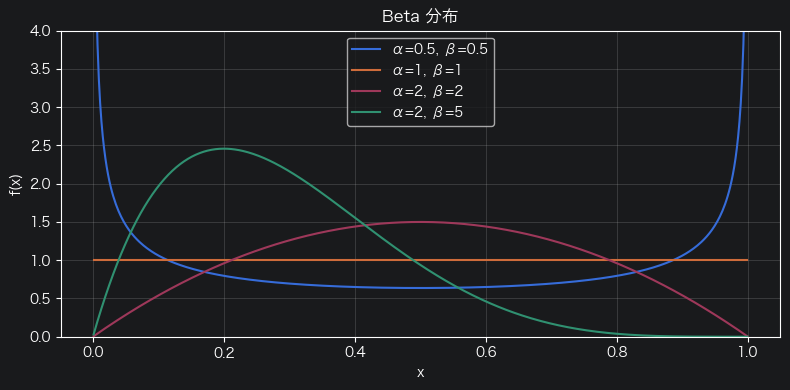

In [40]:
from scipy.stats import beta as beta_dist

x = np.linspace(0.001, 0.999, 500)
params = [(0.5, 0.5), (1, 1), (2, 2), (2, 5)]

plt.figure(figsize=(8, 4))
for a, b in params:
    y = beta_dist.pdf(x, a, b)
    plt.plot(x, y, label=f'α={a}, β={b}')
plt.title('Beta 分布')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(0, 4)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()